In [4]:
# %pip install openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

df = pd.read_csv('../../Datasets/fromclass/ecommerce_sales_data.csv')
house = pd.read_csv('../../Datasets/fromclass/todays_house_with_zipcode.csv')
data = pd.read_excel('../../Datasets/fromclass/head_brain_synthetic_237rows.xlsx')

house.describe()

,YearSold,SqFt,Bedrooms,Bathrooms,GarageCars,LotSize,SalePrice,ZipCode
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2008.000000,2122.715000,3.100000,1.920000,1.010000,8421.035000,401791.485000,10002.410000
std,1.417762,762.476963,1.476789,0.822791,0.795654,3668.553706,116074.327832,1.121691
min,2006.000000,804.000000,1.000000,1.000000,0.000000,2077.000000,179648.000000,10001.000000
25%,2007.000000,1452.000000,2.000000,1.000000,0.000000,5333.000000,311355.500000,10001.000000
50%,2008.000000,2113.500000,3.000000,2.000000,1.000000,8097.000000,411346.500000,10002.000000
75%,2009.000000,2737.000000,4.250000,3.000000,2.000000,11779.250000,493864.000000,10003.000000
max,2010.000000,3460.000000,5.000000,3.000000,2.000000,14999.000000,611178.000000,10004.000000


array([20084.36605919])

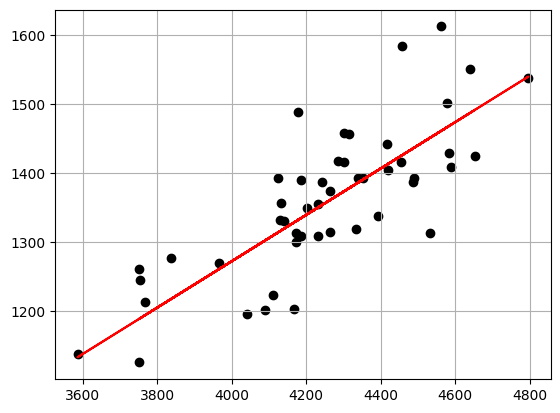

In [5]:

lr = LinearRegression()

def results_df(x_test,y_test, y_prep):
    df= pd.DataFrame({
    'SqFt': x_test['SqFt'].values,
    'Bedrooms': x_test['Bedrooms'].values,
    'Bathrooms': x_test['Bathrooms'].values,
    'GarageCars': x_test['GarageCars'].values,
    'Actual Price (y)': y_test.values,
    'Predicted Price (ŷ)': y_prep.round(2),
    'Residual (y - ŷ)': y_test.values - y_prep
})
    return df

def predic(SqFt, Bedrooms, Bathrooms,GarageCars, zip):

  return lr.predict([[SqFt, Bedrooms, Bathrooms,GarageCars, zip]])[0]

data.head(10)

X = data['Head Size(cm^3)'].values
Y = data['Brain Weight(grams)'].values
X = X.reshape(-1,1)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.20)

lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)
r2 = r2_score(Y_test,Y_pred)
r2
plt.scatter(X_test, Y_test, color='black', label='Actual')
plt.plot(X_test, Y_pred, color='red', label='Test')
plt.grid()
lr.predict([[60000]])

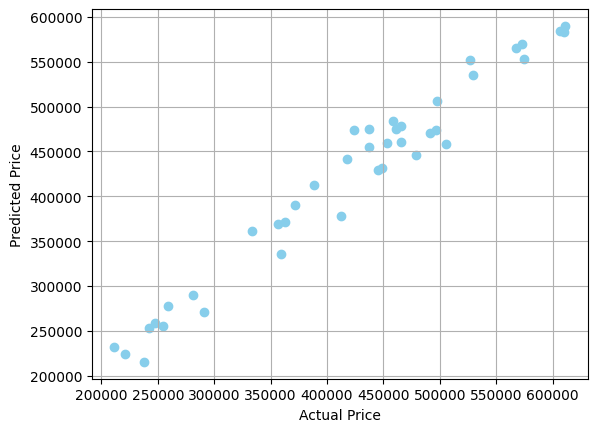

TypeError: LinearModel.predict() takes 2 positional arguments but 6 were given

In [13]:
X = house[['SqFt', 'Bedrooms', 'Bathrooms','GarageCars', 'ZipCode']]
Y = house['SalePrice']


x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
lr.fit(x_train, y_train)

y_prep = lr.predict(x_test)
r2 = r2_score(y_test, y_prep)


plt.scatter(y_test, y_prep, color='skyblue')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.show()

lr.predict(2730, 1, 1, 0, 10004)




In [ ]:
house[['SqFt','Bedrooms', 'Bathrooms', 'GarageCars', 'SalePrice']]
house['SalePrice'].min()

np.int64(179648)